**<center><font size=7>Sentiment Analysis with Word Embeddings and Transformers</font></center>**
<center><p float="center">
  <img src="https://images.openai.com/static-rsc-4/a5Ilb_9xcXLw7uGGWaoLLhGTAArk85_TPoQ8Qldq40_zD47bhITL0MtF4wQV7IWlTCmWVGf7eQyGlnQIw2b8ZGPFwRNCxEhfUeO2-u1Xc83SFyUqBJD2OXxKuKVKqIQ6qDkn5mcQ4uBRPOLyFx5ORT1KxJgGbVBXy5rsICflaj_xfUnExxhnKqR7kyrtAN5z?purpose=fullsize" width="720"/>
</p></center>

# **Problem Statement**

In the fast-evolving landscape of the entertainment industry, it is important to gauge audience sentiments towards movie releases. Understanding the sentiments expressed in movie reviews is crucial for shaping marketing strategies, refining content creation, and ultimately enhancing the overall viewer experience. However, manually analyzing an extensive volume of reviews is time-consuming and may not capture nuanced sentiments at scale. To address this, we aim to develop an AI-based sentiment analyzer that automatically evaluates movie reviews, providing actionable insights into audience perceptions.

## **Data Dictionary**

- **review**: review of a movie
- **sentiment**: indicates the sentiment of the review ( 0 is for negative review and 1 for positive review)

# **Installing and Importing Necessary Libraries**

In [ ]:
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2\
             accelerate==1.7.0\
             sentencepiece==0.2.0

### **Importing Libraries and Setting Up Environment**

This cell is responsible for installing and verifying the versions of several key Python libraries required for this sentiment analysis project. It uses `!pip install` to ensure that specific versions of libraries like `numpy`, `scikit-learn`, `scipy`, `gensim`, `sentence-transformers`, `pandas`, `accelerate`, and `sentencepiece` are installed. Pinning versions helps maintain consistency and reproducibility across different environments. These libraries cover functionalities for numerical operations, machine learning, natural language processing (specifically Word2Vec and Sentence Transformers), and data manipulation.

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

This cell imports all necessary Python libraries for various stages of the sentiment analysis project. It includes:
- **`numpy` and `pandas`**: For numerical operations and data manipulation, especially with DataFrames.
- **`matplotlib.pyplot` and `seaborn`**: For data visualization, such as plotting confusion matrices and distributions.
- **`gensim.models.Word2Vec`**: For generating word embeddings using the Word2Vec algorithm.
- **`torch`**: The PyTorch library, a deep learning framework, although it's primarily used implicitly by `sentence-transformers`.
- **`sentence_transformers.SentenceTransformer`**: For loading pre-trained transformer models to generate sentence embeddings.
- **`T5Tokenizer`, `T5ForConditionalGeneration`, `pipeline` from `transformers`**: These are imported but not directly used in the provided code, indicating a potential for future use of T5 models or general transformer-based pipelines.
- **`sklearn.model_selection.train_test_split`**: To divide the dataset into training and testing subsets.
- **`sklearn.ensemble.RandomForestClassifier`**: To build a Random Forest machine learning model for classification.
- **`sklearn.metrics.accuracy_score`, `confusion_matrix`**: For evaluating model performance.
- **`warnings`**: To suppress unnecessary warning messages during execution.
- **`tensorflow` and `keras`**: For building and training Neural Network models, including `Sequential` models, `Dense` layers, and `Dropout` layers.

# **Importing the dataset**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
reviews = pd.read_csv("/content/drive/MyDrive/Gen AI Dataset/movie_review.csv")

This cell is responsible for loading the dataset into the environment. It reads a CSV file named `movie_review.csv` from a specified Google Drive path (`/content/drive/MyDrive/Gen AI Dataset/movie_review.csv`) and stores it into a pandas DataFrame called `reviews`. This DataFrame will serve as the primary source of raw movie review data for the sentiment analysis task.

In [ ]:
# creating a copy of the data
data = reviews.copy()

This cell creates a deep copy of the `reviews` DataFrame, assigning it to a new variable named `data`. This practice is important for data integrity, as it allows for modifications and manipulations on `data` without altering the original `reviews` DataFrame, ensuring that the raw imported data remains untouched for potential re-use or comparison.

# **Data Overview**

## **Checking the first 5 rows**

In [ ]:
data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

This cell displays the first 5 rows of the `data` DataFrame using the `.head(5)` method. This is a crucial initial step in data exploration, allowing for a quick visual inspection of the dataset's structure, column names, data types, and a sample of the actual review text and sentiment labels. It helps in understanding the format and content of the data at a glance.

* Here, a sentiment value of **0 is negative** and **1 is positive**.

## **Checking the shape of the data**

In [ ]:
data.shape

(9982, 2)

This cell uses the `.shape` attribute to return a tuple representing the dimensionality of the `data` DataFrame. The output `(9982, 2)` indicates that the DataFrame contains 9982 rows (representing individual movie reviews) and 2 columns (typically 'review' and 'sentiment'). This provides a concise overview of the dataset's size.

* The dataset has 10000 rows and 2 columns.

## **Checking for missing values**

In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


This cell performs a check for missing values within the `data` DataFrame. It uses `.isnull()` to create a boolean DataFrame indicating `True` for missing values and `False` otherwise, and then `.sum()` to count the number of `True` values (i.e., missing entries) for each column. The output `review 0` and `sentiment 0` confirms that there are no missing values in either of the columns, ensuring data completeness for subsequent steps.

* There are no missing values in the data

## **Checking for duplicate values**

In [ ]:
# checking for duplicate values
data.duplicated().sum()

0

This cell checks for duplicate rows in the `data` DataFrame. The `.duplicated()` method returns a boolean Series indicating whether each row is a duplicate of a previous row. When chained with `.sum()`, it counts the total number of duplicate rows. An output of `0` means there are no exact duplicate entries in the DataFrame.

In [ ]:
# keeping only the first occurence of duplicate values and dropping the rest
data = data.drop_duplicates(keep = 'first')

This cell addresses data redundancy by removing duplicate rows from the `data` DataFrame. The `drop_duplicates(keep='first')` method ensures that if multiple identical rows exist, only the first occurrence is retained, and all subsequent duplicates are removed. This helps in maintaining a clean and unique dataset for analysis, preventing skewed results due to repeated entries.

In [ ]:
# reseting the index of the dataframe
data = data.reset_index(drop = True)

After removing duplicate rows, the DataFrame's index might no longer be continuous. This cell uses `reset_index(drop=True)` to re-index the `data` DataFrame. The `drop=True` argument prevents the old index from being added as a new column, resulting in a fresh, sequential index from 0 to `n-1` for the updated DataFrame, which is good practice for consistent data handling.

In [ ]:
data

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

This cell displays the entire `data` DataFrame after the cleaning steps (removing duplicates and resetting the index). It provides a complete view of the processed dataset, confirming that the data is now in its finalized form before moving on to embedding and model building. The output shows the number of rows and columns, reflecting any changes made during the data cleaning process.

## **Checking the distribution of sentiments**

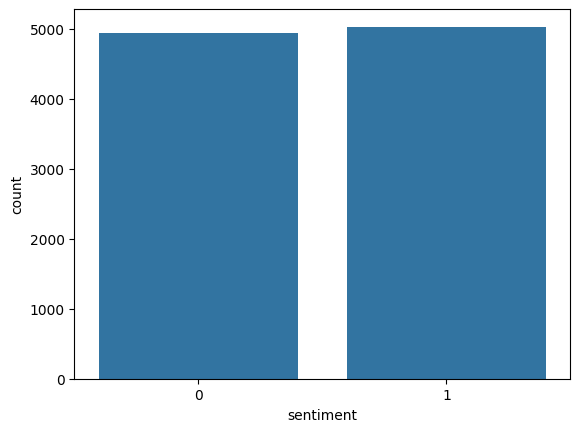

In [ ]:
sns.countplot(data=data, x='sentiment');

This cell generates a countplot using `seaborn` to visualize the distribution of sentiments in the `data` DataFrame. The `x='sentiment'` argument specifies that the 'sentiment' column should be used for counting categories. This plot helps to quickly assess the balance of positive (1) and negative (0) reviews in the dataset, which is important for understanding potential class imbalance issues that could affect model training.

- There are almost an equal number of positive and negative reviews.

# **1. Word2Vec - Text Embedding and Sentiment Analysis**

## **Generating Embeddings with Word2Vec**

- `Word2Vec` is imported from Gensim library

- `Word2Vec` takes the following important parameters:
    1. `word_list`: List of all words in all documents
    2. `vector_size`: Determines the size of the word vectors
    2. `min_count`: It will ignore all the words with a total frequency lower than this.
    3. `workers`: These are the number of threads to train the model.
    4. `window`: Size of context relative to target word.

- By default, it creates word vectors of size 100.

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['review'].values]

This cell performs tokenization on the 'review' column of the `data` DataFrame. For each movie review, it splits the string into a list of individual words using the `split(" ")` method (splitting by spaces). The resulting `words_list` is a list of lists, where each inner list contains the words from a single review. This pre-processing step is essential for preparing the text data for Word2Vec embedding, as Word2Vec operates on individual words.

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

This cell initializes and trains a Word2Vec model using the `gensim` library. It takes the `words_list` (tokenized reviews) as input. Key parameters are:
- `vector_size = 300`: Each word will be represented by a 300-dimensional vector.
- `min_count = 1`: Words that appear at least once will be included in the vocabulary.
- `window = 5`: The maximum distance between the current and predicted word within a sentence.
- `workers = 6`: The number of CPU cores to use for training, speeding up the process.
This model learns vector representations (embeddings) for words, capturing semantic relationships based on their context in the reviews.

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 157460


This cell prints the total number of unique words that the trained `model_W2V` (Word2Vec model) has learned and stored in its vocabulary. `model_W2V.wv.key_to_index` provides a mapping of words to their numerical indices, and `len()` on its keys gives the vocabulary size. This metric indicates the comprehensiveness of the word representations learned from the dataset.

### **Basic Examples**

In [ ]:
model_W2V.wv["good"]

array([ 1.4038773 ,  0.48586774, -0.15350303,  0.6797294 ,  0.8320188 ,
       -1.2404815 ,  1.1699868 , -0.31116536, -0.68959516, -0.8572591 ,
        0.5449326 , -0.34230888,  0.03261304,  0.7887009 , -1.2621965 ,
       -0.0699465 ,  0.65391064, -0.00965948, -0.2354326 , -1.0721502 ,
        1.2900321 ,  0.15900141,  0.2244763 ,  1.2840228 , -0.1612512 ,
       -0.5478289 , -1.015817  , -1.783889  , -1.8143799 , -1.90749   ,
        0.94018906, -0.5249194 ,  0.05833464,  0.9077333 ,  0.9538919 ,
       -1.3398694 ,  0.3365625 , -0.07119954,  1.4095324 , -0.23357973,
        0.12325113, -0.04782305, -0.28607324,  0.685428  ,  1.3945694 ,
        0.37532106, -0.52821946,  1.5127563 ,  0.47983631, -0.10355981,
       -0.87698877,  0.18578793,  0.8220776 , -0.7403126 ,  0.04135042,
        0.33781457,  1.476822  , -0.54840076,  1.0743859 , -1.5471861 ,
       -0.8665022 ,  0.35329762, -0.91715795, -0.10955901, -0.0654419 ,
       -0.23654537, -1.1646082 ,  0.20382513,  1.3421689 , -0.30

This cell demonstrates how to retrieve the vector representation (embedding) for a specific word, 'good', from the trained Word2Vec model. The output is a 300-dimensional NumPy array, where each number is a floating-point value. This vector numerically encapsulates the semantic meaning of the word 'good' based on its context within the training data, allowing for mathematical comparisons with other word vectors.

In [ ]:
model_W2V.wv["best"]

array([-0.3827451 ,  0.45640552, -0.7429451 ,  0.78023005, -0.18722947,
        0.0514081 ,  1.8525008 ,  1.3514131 , -1.2513602 ,  0.10099272,
        0.33439428, -0.32070288, -0.8716841 ,  1.0325317 ,  0.25427994,
       -0.64199543,  1.3284848 , -1.3348289 ,  0.04665715, -0.4891179 ,
        1.2969432 ,  1.474746  ,  0.26185775,  0.24192257,  0.4291315 ,
       -1.9848374 , -0.65351933, -0.32192412,  0.44709757, -1.2103895 ,
        1.0439726 ,  0.9502375 , -1.7855765 ,  0.99641645,  0.91883934,
       -0.94851816,  0.8269217 , -0.44237617,  1.707533  , -0.06439529,
       -1.0331709 ,  0.29373825,  0.19591178,  0.64249986,  1.3353311 ,
       -0.2142975 , -0.67040825,  0.7731343 , -0.1586209 ,  0.6822289 ,
       -1.0418084 ,  1.0329925 ,  0.61297053,  0.9964357 ,  0.07990904,
       -1.0839694 ,  0.5910945 , -0.33112776,  1.0643314 , -0.25480714,
       -0.5425699 , -0.7195249 , -1.2097237 , -0.68222404, -1.2978009 ,
       -0.3377493 , -1.1618321 , -1.3126849 , -0.09379707, -1.17

Similar to the previous cell, this code retrieves and displays the 300-dimensional vector embedding for the word 'best' from the trained Word2Vec model. By comparing this vector with the 'good' vector, one could, in theory, observe how the model distinguishes or relates semantically similar but distinct words through their numerical representations. It further illustrates the model's ability to convert lexical items into a continuous vector space.

### **Encoding the dataset**

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

This cell constructs a dictionary (`word_vector_dict`) that maps each word in the Word2Vec model's vocabulary to its corresponding 300-dimensional vector embedding. First, it extracts all unique words (`words`) from the model's vocabulary. Then, it retrieves the vector representations (`wvs`) for these words. Finally, `zip()` is used to pair words with their vectors, creating a convenient lookup dictionary. This dictionary will be used to efficiently retrieve word embeddings when constructing document-level embeddings.

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

This cell defines a function, `average_vectorizer_Word2Vec`, which converts an entire document (movie review) into a single fixed-size vector. It works by:
1.  **Initializing a zero vector**: A `feature_vector` of the specified `vec_size` (300) is created.
2.  **Filtering words**: It identifies words in the input `doc` that are present in the Word2Vec model's vocabulary.
3.  **Summing vectors**: For each valid word, its corresponding vector from `word_vector_dict` is added to the `feature_vector`.
4.  **Averaging**: The summed vector is then divided by the total number of valid words to compute the average vector for the document. This average vector represents the overall semantic content of the document. This approach assumes that the average of word vectors adequately captures the meaning of a longer text.

In [ ]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['review'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.280768,-0.363439,-0.094192,0.087287,0.069671,-0.470058,0.599703,0.850811,0.005173,-0.301172,...,0.042741,0.520748,0.304086,0.253520,0.770695,0.670765,-0.047028,-0.390668,0.393772,-0.131235
1,0.190006,-0.178987,-0.052848,-0.015991,0.107380,-0.383911,0.628857,0.608969,-0.082866,-0.214686,...,0.103259,0.336104,0.101028,0.160054,0.456683,0.715323,-0.062368,-0.327765,0.314685,-0.285066
2,0.302196,-0.213538,-0.063633,0.173177,0.105820,-0.457673,0.548897,0.711516,-0.093759,-0.200350,...,0.037682,0.341884,0.145051,0.120956,0.490522,0.698902,-0.103379,-0.313854,0.328708,-0.257542
3,0.306586,-0.175347,-0.004800,0.038173,0.128381,-0.362963,0.678696,0.554112,-0.016166,-0.323350,...,0.105224,0.312170,-0.058074,0.095216,0.438452,0.809912,-0.004237,-0.278061,0.342784,-0.238395
4,0.321411,-0.233035,-0.097779,0.078785,0.129225,-0.417118,0.791151,0.645987,0.047350,-0.306467,...,0.052836,0.301627,0.013564,0.108856,0.532173,0.793558,0.014912,-0.370635,0.430484,-0.166007


This cell applies the `average_vectorizer_Word2Vec` function to every review in the 'review' column of the `data` DataFrame. The `.apply()` method iterates through each review, generates its average Word2Vec embedding, and `tolist()` converts the resulting NumPy arrays into a list of lists. This list is then used to create a new pandas DataFrame, `df_Word2Vec`, where each row represents a review, and each column (`Feature 0` to `Feature 299`) corresponds to a dimension of the 300-dimensional embedding vector. The `.head()` call displays the first few rows of this new DataFrame, showing the vectorized representations of the reviews.

## **Random Forest : Sentiment Analysis by Word2Vec**

In [ ]:
# Define a function to plot the confusion matrix
def plot_confusion_matrix(actual, predicted):
    # Calculate the confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Create a figure for the plot
    plt.figure(figsize = (5, 4))
    # Define labels for the plot axes
    label_list = ['negative', 'positive']
    # Create a heatmap of the confusion matrix
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    # Set the y-axis label
    plt.ylabel('Actual')
    # Set the x-axis label
    plt.xlabel('Predicted')
    # Display the plot
    plt.show()

This cell defines a utility function named `plot_confusion_matrix` which is designed to visualize the performance of a classification model. The function takes two arguments: `actual` (the true labels) and `predicted` (the model's predicted labels).

Inside the function:
1.  **`confusion_matrix(actual, predicted)`**: Calculates the confusion matrix, which is a table used to describe the performance of a classification model on a set of test data for which the true values are known.
2.  **`plt.figure(figsize = (5, 4))`**: Creates a new figure for plotting with a specified size.
3.  **`label_list = ['negative', 'positive']`**: Defines custom labels for the sentiment classes, making the plot more readable.
4.  **`sns.heatmap(...)`**: Generates a heatmap visualization of the confusion matrix. `annot=True` displays the values in each cell, `fmt='.0f'` formats these values as integers, and `xticklabels`/`yticklabels` set the axis labels to 'negative' and 'positive'.
5.  **`plt.ylabel('Actual')` and `plt.xlabel('Predicted')`**: Sets the labels for the y-axis and x-axis of the plot.
6.  **`plt.show()`**: Displays the generated confusion matrix plot. This function is reusable and will be called multiple times throughout the notebook to visualize the performance of different models on training and test data.

In [ ]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.sentiment

This cell prepares the data for machine learning model training. It assigns:
-   `X = df_Word2Vec.copy()`: The `df_Word2Vec` DataFrame, which contains the Word2Vec embeddings (numerical features) for each review, is assigned to `X`. This `X` represents the independent variables or features that the models will use for prediction.
-   `y = data.sentiment`: The 'sentiment' column from the original `data` DataFrame, containing the target labels (0 for negative, 1 for positive), is assigned to `y`. This `y` represents the dependent variable or the target that the models will try to predict.
This separation of features and target is standard practice in supervised learning.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

This cell splits the dataset into training and testing sets, a critical step to evaluate a model's generalization ability. It uses `train_test_split` from `sklearn.model_selection` with the following parameters:
-   `X`, `y`: The feature matrix and target vector.
-   `test_size = 0.2`: 20% of the data will be allocated to the test set, and 80% to the training set.
-   `random_state = 42`: This ensures reproducibility of the split. Running the code multiple times with the same `random_state` will always yield the same train/test division.
This results in `X_train`, `X_test`, `y_train`, and `y_test`, which will be used for training and evaluating models, respectively.

In [ ]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

This cell initializes and trains a Random Forest Classifier model.
-   **`rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)`**: A Random Forest model is instantiated with `100` decision trees (`n_estimators`), a maximum depth of `3` for each tree (`max_depth`) to prevent individual trees from overfitting, and a `random_state` of `42` for reproducibility.
-   **`rf_word2vec.fit(X_train, y_train)`**: The model is then trained (`fit`) using the Word2Vec features (`X_train`) and their corresponding sentiment labels (`y_train`) from the training set. This process involves the ensemble of decision trees learning the patterns and relationships between the word embeddings and the sentiment classes.

### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

This cell uses the trained `rf_word2vec` Random Forest model to make predictions on both the training and testing datasets.
-   **`y_pred_train = rf_word2vec.predict(X_train)`**: Generates sentiment predictions for the training data (`X_train`). These predictions are used to assess how well the model learned the training patterns.
-   **`y_pred_test = rf_word2vec.predict(X_test)`**: Generates sentiment predictions for the unseen test data (`X_test`). These predictions are crucial for evaluating the model's ability to generalize to new, previously unobserved reviews.
Both `y_pred_train` and `y_pred_test` will contain binary labels (0 or 1) representing the predicted sentiment.

**Confusion Matrix**

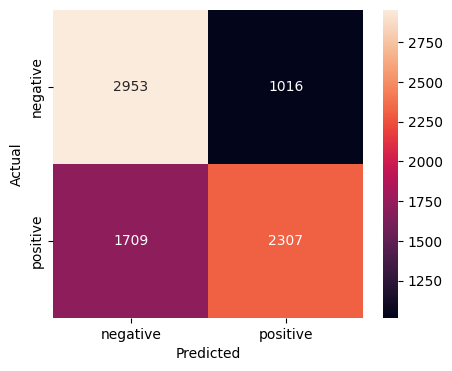

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

This cell calls the previously defined `plot_confusion_matrix` function to visualize the performance of the `rf_word2vec` model on the **training data**. It compares the `y_train` (actual training sentiments) with `y_pred_train` (predicted training sentiments). The resulting confusion matrix provides a detailed breakdown of correct and incorrect classifications (true positives, true negatives, false positives, false negatives) within the data the model was trained on.

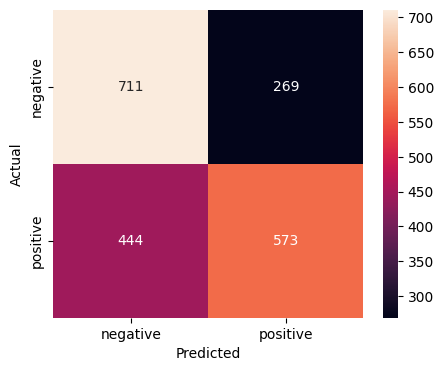

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

This cell calls the `plot_confusion_matrix` function to visualize the performance of the `rf_word2vec` model on the **testing data**. It compares the `y_test` (actual test sentiments) with `y_pred_test` (predicted test sentiments). This confusion matrix is critical for evaluating the model's generalization capability on unseen data, showing how well it performs beyond what it was explicitly trained on. A good model should perform similarly on both training and test confusion matrices, indicating low bias and variance.

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)

The accuracy on the training set is:  0.6587351283656857
The accuracy on the test set is:  0.642964446670005


This cell calculates and prints the accuracy scores for the `rf_word2vec` model on both the training and testing datasets.
-   **`train_accuracy_Word2Vec_RF = accuracy_score(y_train, y_pred_train)`**: Computes the proportion of correctly predicted sentiments on the training data. This indicates how well the model fit the data it learned from.
-   **`test_accuracy_Word2Vec_RF = accuracy_score(y_test, y_pred_test)`**: Computes the proportion of correctly predicted sentiments on the unseen test data. This is a crucial metric for evaluating the model's generalization performance. The difference between training and test accuracy helps in identifying overfitting or underfitting.

## **Nueral Networks : Sentiment Analysis by Word2Vec**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,914 (183.26 KB)

 Trainable params: 46,914 (183.26 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines a Neural Network model using TensorFlow and Keras to classify sentiments based on Word2Vec embeddings.
-   **`tf.keras.backend.clear_session()` and `gc.collect()`**: Clears previous Keras sessions and performs garbage collection to free up memory, ensuring a clean slate for model definition.
-   **`model = Sequential()`**: Initializes a linear stack of layers for the neural network.
-   **`Dense(128, activation='relu', input_shape=(X_train.shape[1],))`**: Adds the first hidden layer with 128 neurons, a ReLU activation function, and specifies the input shape (number of features, which is the dimensionality of Word2Vec embeddings).
-   **`Dropout(0.3)`**: Introduces a dropout layer, randomly setting 30% of input units to 0 during training to prevent overfitting.
-   **`Dense(64, activation='relu')`**: Adds a second hidden layer with 64 neurons and ReLU activation.
-   **`Dense(2, activation='softmax')`**: Defines the output layer with 2 neurons (for two sentiment classes: positive/negative) and a softmax activation function to output class probabilities.
-   **`model.compile(...)`**: Configures the model for training with the Adam optimizer, `sparse_categorical_crossentropy` as the loss function (suitable for integer labels), and 'accuracy' as the evaluation metric.
-   **`model.summary()`**: Prints a summary of the model's architecture, including the number of layers, output shapes, and total parameters.

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5974 - loss: 0.6602 - val_accuracy: 0.6560 - val_loss: 0.6206
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6710 - loss: 0.6090 - val_accuracy: 0.6865 - val_loss: 0.5929
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6893 - loss: 0.5894 - val_accuracy: 0.6725 - val_loss: 0.6008
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6920 - loss: 0.5818 - val_accuracy: 0.7091 - val_loss: 0.5672
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7087 - loss: 0.5690 - val_accuracy: 0.7056 - val_loss: 0.5725
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7033 - loss: 0.5664 - val_accuracy: 0.7071 - val_loss: 0.5647
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7090 - loss: 0.5703 - val_accuracy: 0.7001 - val_loss: 0.5678
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7073 - loss: 0.5707 - val_accuracy: 0.

This cell trains the defined Neural Network model using the Word2Vec embeddings.
-   **`model.fit(...)`**: Initiates the training process.
-   **`X_train`, `y_train`**: The training features (Word2Vec embeddings) and corresponding labels.
-   **`validation_data=(X_test, y_test)`**: The model is evaluated on the test set (`X_test`, `y_test`) after each epoch, providing insights into its generalization performance during training.
-   **`epochs=20`**: The model will iterate over the entire training dataset 20 times.
-   **`batch_size=32`**: The training data will be divided into mini-batches of 32 samples, and the model's weights will be updated after processing each batch. The `history` object stores details about the training progress, including loss and accuracy for both training and validation sets over epochs.

### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


**Confusion Matrix**

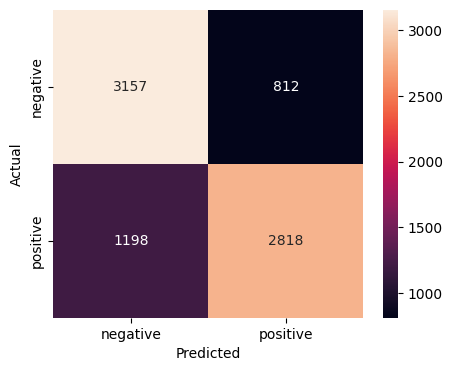

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

This cell calls the `plot_confusion_matrix` function to visualize the Neural Network model's classification performance on the **training data**. It takes the actual training labels (`y_train`) and the model's predicted labels for the training set (`y_train_preds`) as input. The resulting heatmap shows the counts of true positives, true negatives, false positives, and false negatives, providing a visual assessment of how well the Neural Network learned the patterns within the data it was trained on.

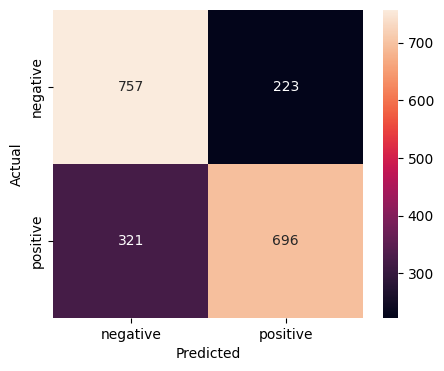

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

This cell calls the `plot_confusion_matrix` function to visualize the Neural Network model's classification performance on the **testing data**. It compares the actual test labels (`y_test`) with the model's predicted labels for the test set (`y_test_preds`). This visualization is crucial for understanding the model's generalization ability to unseen data. It allows for quick identification of areas where the model might be struggling (e.g., misclassifying positive as negative or vice versa) when faced with new inputs.

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.7482780212899186
The accuracy on the test set is:  0.7275913870806209


This cell calculates and prints the accuracy scores for the Neural Network model (using Word2Vec embeddings) on both the training and testing datasets.
-   **`train_accuracy_Word2Vec_NN = accuracy_score(y_train, y_train_preds)`**: Measures the proportion of correct predictions on the training data, indicating how well the model learned from its training examples.
-   **`test_accuracy_Word2Vec_NN = accuracy_score(y_test, y_test_preds)`**: Measures the proportion of correct predictions on the unseen test data, which is a key indicator of the model's ability to generalize to new, real-world data. Comparing these two accuracies helps to detect overfitting or underfitting.

# **2. Transformers - Text Embedding and Sentiment Analysis**

## **Generating Embeddings with Sentence Tranformers**

We'll be using the **all-MiniLM-L6-v2** model here.

- The **all-MiniLM-L6-v2** model is an all-round (**all**) model trained on a large and diverse dataset of over 1 billion training samples and generates state-of-the-art sentence embeddings of 384 dimensions.

- It is a language model (**LM**) that has 6 transformer encoder layers (**L6**) and is a smaller model (**Mini**) trained to mimic the performance of a larger model (BERT).

-  Potential use-cases include text classification, sentiment analysis, and semantic search.

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

This cell initializes a `SentenceTransformer` model using the pre-trained 'sentence-transformers/all-MiniLM-L6-v2' model. This specific model is chosen for its efficiency and effectiveness in generating high-quality sentence embeddings (vector representations of entire sentences). The `model` object loaded here will be used in subsequent steps to convert movie reviews into numerical vectors that capture their semantic meaning, preparing them for machine learning tasks.

- There are many other models to choose from too!
- One place to check for the best models is the [HuggingFace leaderboard](https://www.sbert.net/docs/pretrained_models.html).
- Below is an example of another model that one can use in this case.

> `model = SentenceTransformer('BAAI/bge-base-en-v1.5')`

### **Basic Examples**

In [ ]:
model.encode(['Hello, my name is Prof. Zena!'])

array([[-1.01322196e-01,  2.77659651e-02, -4.15140167e-02,
         1.84561331e-02, -4.85775098e-02, -1.63206980e-02,
         1.31670907e-01, -2.84867585e-02,  2.94027105e-03,
        -2.18541548e-02, -5.48136197e-02, -9.36226081e-03,
        -1.48072606e-02,  2.78399605e-02, -3.74657623e-02,
        -4.98651643e-04, -6.98258914e-03, -2.66996603e-02,
        -3.89730930e-02, -2.10851002e-02, -9.75728966e-03,
        -1.97300152e-03,  5.53301498e-02, -3.02358530e-02,
        -7.95633122e-02, -1.13197053e-02, -1.35750854e-02,
         1.47868795e-02, -3.55500705e-03, -7.07181171e-02,
         2.56204475e-02,  6.83853254e-02,  2.18798555e-02,
        -1.32915529e-03,  5.71828224e-02,  5.70111908e-02,
        -6.20051324e-02, -1.44120688e-02,  7.99196865e-03,
         7.58336857e-04,  1.20889815e-03,  6.11671666e-03,
        -8.94941986e-02, -3.09460168e-03, -5.15797921e-02,
        -4.05938737e-02,  6.07262924e-02, -1.10700633e-02,
         6.72289878e-02, -3.69399451e-02, -9.92941856e-0

This cell provides a basic example of how to use the loaded `SentenceTransformer` model to encode text. It takes a list containing a single sentence, `['Hello, my name is Prof. Zena!']`, and converts it into a high-dimensional vector representation. The output is a NumPy array representing the embedding of that sentence. This demonstrates the core functionality of the Sentence Transformer: turning human language into numerical data that machine learning models can process.

In [ ]:
model.encode(['Hello, my name is Professor Zena!'])

array([[-1.11282602e-01,  4.16151769e-02, -4.53358889e-02,
         1.95421576e-02, -6.02429882e-02, -3.59271988e-02,
         9.60513577e-02, -5.55648804e-02,  2.31815446e-02,
        -6.68977946e-03, -2.75410060e-02,  9.78378300e-03,
        -4.83657001e-03,  4.17626053e-02, -5.34442291e-02,
        -3.23547050e-04, -1.19966827e-02, -5.33526130e-02,
        -3.72466594e-02,  5.55628678e-03, -4.23140032e-03,
         2.12436840e-02,  4.35178429e-02, -2.97153555e-02,
        -6.82366192e-02,  1.11056603e-02,  1.19564170e-02,
        -3.14616552e-03, -1.08422143e-02, -6.52326345e-02,
         1.06411679e-02,  6.62760437e-02,  7.96016026e-03,
        -1.82570405e-02,  4.55049314e-02,  3.26332897e-02,
        -3.87101732e-02, -6.36683730e-03,  3.26532610e-02,
        -8.85265134e-03,  2.78327568e-03,  2.53109559e-02,
        -6.47957101e-02, -2.17167363e-02, -5.99524081e-02,
        -2.76416708e-02,  6.41192943e-02, -3.19894478e-02,
         8.19110945e-02, -4.25210595e-02, -7.33607784e-0

This cell presents another example of sentence encoding using the `SentenceTransformer` model. It encodes the sentence `['Hello, my name is Professor Zena!']`, which is semantically very similar to the previous example, but with a slight lexical difference ('Prof.' vs 'Professor'). By observing the output embedding, one can infer how robust the model is to minor variations in phrasing, as similar sentences should ideally produce similar embedding vectors in the semantic space. This reinforces the model's capability to capture semantic meaning rather than just keyword matching.

### **Encoding the dataset**

In [ ]:
# encoding the dataset
embedding_matrix = model.encode(data['review'], show_progress_bar=True)

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

This cell is crucial for transforming the entire movie review dataset into numerical embeddings using the `SentenceTransformer` model. It applies the `model.encode()` method to the 'review' column of the `data` DataFrame. The `show_progress_bar=True` argument displays a progress bar during the encoding process, which can be time-consuming for large datasets. The output, `embedding_matrix`, is a NumPy array where each row is the high-dimensional embedding vector for a single movie review, ready to be used as features for machine learning models.

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(9982, 384)

This cell prints the shape of the `embedding_matrix` generated by the `SentenceTransformer`. The output `(9982, 384)` indicates that there are 9982 reviews (rows), and each review has been transformed into a 384-dimensional vector (columns). This confirms the number of samples in the dataset and the dimensionality of the sentence embeddings produced by the 'all-MiniLM-L6-v2' model, providing a concise summary of the encoded data's structure.

In [ ]:
# printing the embedding vector of the first review in the dataset
embedding_matrix[0,:]

array([-7.45214149e-02,  2.59456411e-03, -3.34988907e-02, -4.84162644e-02,
       -3.84775251e-02,  6.37952834e-02,  5.54265268e-03,  4.06936556e-02,
        6.29823580e-02, -3.84879708e-02, -1.27105061e-02, -2.12660301e-02,
        6.79038689e-02,  2.27336353e-03,  1.14880851e-03,  2.30603516e-02,
        8.18005055e-02,  4.14928496e-02, -2.12946702e-02, -2.29654647e-02,
        2.09020432e-02, -2.93925442e-02,  9.37751159e-02, -2.93005202e-02,
       -6.34454638e-02, -1.70641728e-02,  1.12413347e-01, -2.24412419e-02,
       -6.00714348e-02,  1.55951604e-02,  2.08699889e-02,  7.55285397e-02,
       -6.04214668e-02,  2.33692699e-03, -1.79052930e-02,  7.56649822e-02,
        9.78589524e-03,  2.67772693e-02, -1.30182290e-02, -1.76513698e-02,
        3.84344533e-02,  3.93548310e-02,  5.56520447e-02, -1.35076242e-02,
        5.03627956e-02, -7.22084865e-02, -2.37328969e-02, -1.08479731e-01,
        2.67260782e-02, -5.05364686e-02, -8.09637830e-02,  5.58139868e-02,
       -1.44371507e-03, -

This cell displays the full 384-dimensional embedding vector for the first review in the `embedding_matrix`. By indexing `embedding_matrix[0,:]`, it retrieves all the numerical values that represent the semantic content of the very first movie review in the dataset. This provides a concrete example of the output of the Sentence Transformer encoding process for a single text input.

**Important Note**
- The model used here is pre-trained and has not been trained or fine-tuned on this specific dataset. As a result, its performance may not be optimal.

## **Random Forest : Sentiment Analysis by Transformers**

In [ ]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["sentiment"]

This cell prepares the Sentence Transformer embeddings for machine learning model training, similar to how Word2Vec features were prepared earlier.
-   **`X = embedding_matrix`**: The `embedding_matrix`, containing the Sentence Transformer embeddings for each review, is assigned to `X`. This now serves as the feature matrix for models using these embeddings.
-   **`y = data["sentiment"]`**: The 'sentiment' column from the original `data` DataFrame remains the target variable, `y`. This consistent assignment allows for training and evaluating models with different embedding techniques while keeping the target consistent.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell divides the dataset, now represented by Sentence Transformer embeddings, into training and testing sets. It uses `train_test_split` with the same parameters as before:
-   `X`, `y`: The Sentence Transformer feature matrix and the sentiment target vector.
-   `test_size=0.2`: 20% of the data is allocated for testing.
-   `random_state=42`: Ensures the reproducibility of the split.
This step creates `X_train`, `X_test`, `y_train`, and `y_test` specifically for models that will utilize the Sentence Transformer embeddings.

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

This cell initializes and trains a Random Forest Classifier model, specifically for use with the Sentence Transformer embeddings.
-   **`rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)`**: A Random Forest model is created with 100 decision trees, a maximum depth of 3 for each tree, and a fixed random state for reproducibility. These parameters are chosen to create a relatively simple model to observe the impact of the embedding technique.
-   **`rf_transformer.fit(X_train, y_train)`**: The model is then trained using the `X_train` (Sentence Transformer embeddings) and `y_train` (corresponding sentiment labels) from the training set. This process involves the ensemble learning algorithm discovering patterns within the higher-dimensional semantic space provided by the Sentence Transformers.

### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

This cell generates sentiment predictions using the trained `rf_transformer` (Sentence Transformer with Random Forest) model.
-   **`y_pred_train = rf_transformer.predict(X_train)`**: Predicts sentiment labels for the training dataset. This helps evaluate the model's performance on known data.
-   **`y_pred_test = rf_transformer.predict(X_test)`**: Predicts sentiment labels for the unseen test dataset. This is the crucial step for assessing the model's generalization capabilities on new movie reviews. The output of these predictions will be binary (0 or 1).

**Confusion Matrix**

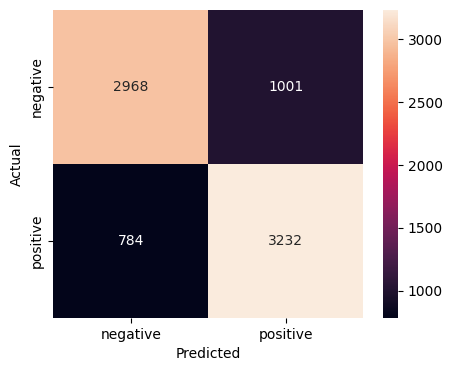

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

This cell visualizes the performance of the `rf_transformer` model on the **training data** by calling the `plot_confusion_matrix` function. It compares the actual training sentiments (`y_train`) with the sentiments predicted by the model on the training data (`y_pred_train`). The resulting confusion matrix provides a clear, numerical and graphical summary of how accurately the model classified sentiments it was trained on, including counts of true positives, true negatives, false positives, and false negatives.

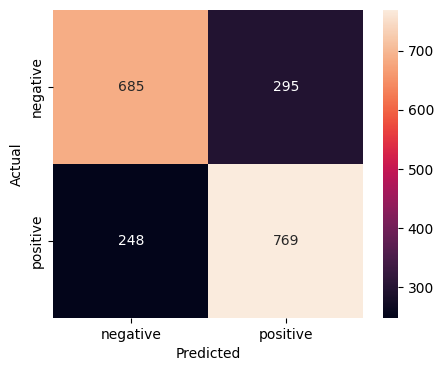

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

This cell visualizes the performance of the `rf_transformer` model on the **testing data** by calling the `plot_confusion_matrix` function. It compares the actual test sentiments (`y_test`) with the sentiments predicted by the model on the unseen test data (`y_pred_test`). This is a critical evaluation step as it demonstrates the model's ability to generalize to new, unobserved data, and helps in identifying potential issues like overfitting or underfitting by comparing it to the training confusion matrix.

**Accuracy**

In [ ]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)

The accuracy on the training set is:  0.7764558547276142
The accuracy on the test set is:  0.728092138207311


This cell calculates and prints the accuracy scores for the `rf_transformer` model (Sentence Transformer with Random Forest) on both the training and testing datasets.
-   **`train_accuracy_transformer_RF = accuracy_score(y_train, y_pred_train)`**: Computes the percentage of correct predictions on the training data, indicating how well the model fit the data it learned from.
-   **`test_accuracy_transformer_RF = accuracy_score(y_test, y_pred_test)`**: Computes the percentage of correct predictions on the unseen test data. This is a primary metric to evaluate the model's generalization performance and is crucial for comparing different models and embedding techniques.

## **Neural Networks : Sentiment Analysis by Transformers**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,666 (225.26 KB)

 Trainable params: 57,666 (225.26 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines a Neural Network model using TensorFlow and Keras, specifically configured to classify sentiments using Sentence Transformer embeddings. It largely mirrors the Word2Vec-NN model definition but is designed to work with the different input dimensionality of Sentence Transformers.
-   **`tf.keras.backend.clear_session()` and `gc.collect()`**: Clears previous Keras sessions and memory.
-   **`model = Sequential()`**: Initializes a new sequential model.
-   **`Dense(128, activation='relu', input_shape=(X_train.shape[1],))`**: The input layer is adjusted to the dimensionality of the Sentence Transformer embeddings (384 features).
-   **`Dropout(0.3)`**: A dropout layer for regularization.
-   **`Dense(64, activation='relu')`**: A second hidden layer.
-   **`Dense(2, activation='softmax')`**: The output layer for binary classification.
-   **`model.compile(...)`**: Compiles the model with the Adam optimizer, `sparse_categorical_crossentropy` loss, and 'accuracy' metric.
-   **`model.summary()`**: Prints the model's architecture, confirming the layer configurations and parameter counts.

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
    )

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7504 - loss: 0.5071 - val_accuracy: 0.7957 - val_loss: 0.4263
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8054 - loss: 0.4227 - val_accuracy: 0.7832 - val_loss: 0.4415
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8230 - loss: 0.4020 - val_accuracy: 0.7932 - val_loss: 0.4175
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8307 - loss: 0.3776 - val_accuracy: 0.8117 - val_loss: 0.4087
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8502 - loss: 0.3499 - val_accuracy: 0.8137 - val_loss: 0.4121
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8671 - loss: 0.3233 - val_accuracy: 0.8112 - val_loss: 0.4197
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8800 - loss: 0.2938 - val_accuracy: 0.8087 - val_loss: 0.4299
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8918 - loss: 0.2650 - val_accuracy: 

This cell trains the Neural Network model that uses Sentence Transformer embeddings.
-   **`model.fit(...)`**: Executes the training process.
-   **`X_train`, `y_train`**: The training features (Sentence Transformer embeddings) and their corresponding labels.
-   **`validation_data=(X_test, y_test)`**: The model's performance is continuously monitored on the unseen test set during training, providing insight into its generalization capabilities as it learns.
-   **`epochs=20`**: The training algorithm will perform 20 full passes over the training data.
-   **`batch_size=32`**: The training data is processed in batches of 32 samples. The `history` object records the training and validation loss and accuracy for each epoch, which can be used to plot learning curves and diagnose overfitting/underfitting.

### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


This cell generates sentiment predictions for the **training dataset** using the trained Neural Network model that was built with Sentence Transformer embeddings.
-   **`y_train_pred_probs = model.predict(X_train)`**: The model outputs the predicted probabilities for each class (negative/positive) for every review in the training set.
-   **`y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()`**: These probabilities are then converted into discrete class labels (0 or 1) by selecting the class with the highest probability. This array of predicted labels will be used to evaluate the model's accuracy on the training data.

This cell uses the trained Neural Network model to make predictions on the **training data**.
-   **`y_train_pred_probs = model.predict(X_train)`**: The model generates probability distributions over the two sentiment classes for each training sample. The output `y_train_pred_probs` is a 2D array where each row represents a sample, and columns are probabilities for negative and positive sentiment.
-   **`y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()`**: `tf.argmax()` selects the index (0 for negative, 1 for positive) corresponding to the highest probability for each sample, effectively converting the probability distribution into a predicted class label. `.numpy()` converts the TensorFlow tensor to a NumPy array for easier handling with scikit-learn metrics.

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


This cell obtains sentiment predictions for the **testing dataset** from the Neural Network model trained with Sentence Transformer embeddings.
-   **`y_test_pred_probs = model.predict(X_test)`**: The model calculates the probability for each sentiment class for every review in the unseen test set.
-   **`y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()`**: The probabilities are then converted into concrete class predictions (0 for negative, 1 for positive). This `y_test_preds` array is essential for assessing the model's generalization ability on data it has not encountered during training.

This cell performs prediction on the **testing data** using the trained Neural Network model, similar to how predictions were made for the training data.
-   **`y_test_pred_probs = model.predict(X_test)`**: Generates probability distributions for sentiment classes for each sample in the unseen test set.
-   **`y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()`**: Converts these probabilities into definitive predicted class labels (0 or 1) for the test set. These predictions will be used to evaluate the model's performance on unseen data.

**Confusion Matrix**

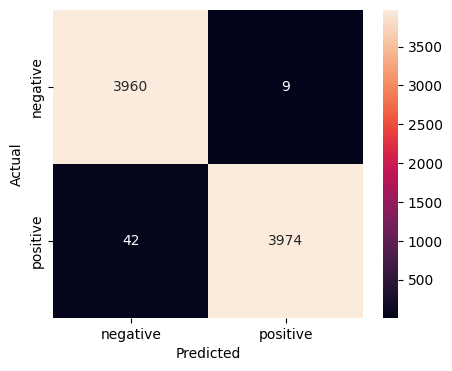

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

This cell calls the `plot_confusion_matrix` function to visually represent the Neural Network model's performance on the **training data** when using Sentence Transformer embeddings. It compares the actual sentiments (`y_train`) with the model's predicted sentiments (`y_train_preds`) for the training set. The resulting heatmap helps to understand how well the neural network learned to classify the sentiments within the data it was trained on.

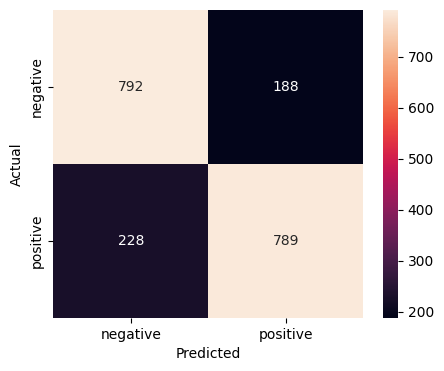

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

This cell calls the `plot_confusion_matrix` function to visualize the Neural Network model's performance on the **testing data** when using Sentence Transformer embeddings. It compares the actual sentiments (`y_test`) with the model's predicted sentiments (`y_test_preds`) for the unseen test set. This visualization is crucial for assessing the model's ability to generalize to new data and can highlight areas of misclassification or potential overfitting if the test performance significantly deviates from the training performance.

**Accuracy**

In [ ]:
train_accuracy_transformer_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the training set is: ",train_accuracy_transformer_NN)
test_accuracy_transformer_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_transformer_NN)

The accuracy on the training set is:  0.993613024420789
The accuracy on the test set is:  0.7916875312969455


This cell calculates and prints the accuracy scores for the Neural Network model (trained with Sentence Transformer embeddings) on both the training and testing datasets.
-   **`train_accuracy_transformer_NN = accuracy_score(y_train, y_train_preds)`**: This metric shows the proportion of correct predictions on the training data, indicating the model's fit to the data it learned from.
-   **`test_accuracy_transformer_NN = accuracy_score(y_test, y_test_preds)`**: This metric represents the proportion of correct predictions on the unseen test data, serving as the primary indicator of the model's generalization capability. A significant difference between train and test accuracy might suggest overfitting.

# **Model Perfomance Comparison**

In [ ]:
# Create a dictionary to compare different models and their accuracies
model_comp = {
    'Model': [
        'Word2Vec-RF',
        'Sentence-Transformer-RF',
        'Word2Vec-NN',
        'Sentence-Transformer-NN'
    ],
    'Train Accuracy': [
        train_accuracy_Word2Vec_RF,
        train_accuracy_transformer_RF,
        train_accuracy_Word2Vec_NN,
        train_accuracy_transformer_NN
    ],
    'Test Accuracy': [
        test_accuracy_Word2Vec_RF,
        test_accuracy_transformer_RF,
        test_accuracy_Word2Vec_NN,
        test_accuracy_transformer_NN
    ]
}

# Creating the DataFrame
model_comp_df = pd.DataFrame(model_comp)

model_comp_df

,Model,Train Accuracy,Test Accuracy
0,Word2Vec-RF,0.658735,0.642964
1,Sentence-Transformer-RF,0.776456,0.728092
2,Word2Vec-NN,0.748278,0.727591
3,Sentence-Transformer-NN,0.993613,0.791688


This cell aggregates and compares the performance of all four models developed in the notebook: Word2Vec with Random Forest, Sentence Transformer with Random Forest, Word2Vec with Neural Network, and Sentence Transformer with Neural Network.
-   It constructs a dictionary `model_comp` containing the 'Model Name', 'Train Accuracy', and 'Test Accuracy' for each model, using the previously calculated accuracy scores.
-   This dictionary is then converted into a pandas DataFrame `model_comp_df`.
-   Finally, `model_comp_df` is displayed, providing a clear, tabular summary for easy comparison of each model's training and generalization performance. This table is essential for identifying the best-performing model and understanding the trade-offs between different embedding techniques and model architectures.

### **Observation for Sentence-Transformer-RF on Unseen Data (Full Test Set)**

The `Sentence-Transformer-RF` model, compared to the `Word2Vec-RF` model, shows improved performance. With a training accuracy of **0.776456** and a test accuracy of **0.728092**, it demonstrates a reasonable ability to generalize to unseen data without significant overfitting. The gap between training and testing accuracy is manageable, suggesting the model learns patterns effectively without memorizing the training set. This improvement is attributed to Sentence Transformers' ability to capture richer semantic meanings at the sentence level, which helps in reducing the underfitting issues observed with simpler embedding methods like Word2Vec when used with Random Forests.

#### **Confusion Matrix and Accuracy for Sentence-Transformer-RF on the entire Test Set**

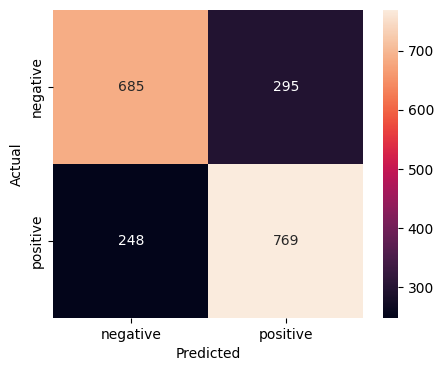

Test Accuracy for Sentence-Transformer-RF: 0.728092138207311


In [ ]:
plot_confusion_matrix(y_test, y_pred_test)
print(f"Test Accuracy for Sentence-Transformer-RF: {test_accuracy_transformer_RF}")

---

# **Prediction On New Data**

### **Demonstration on a Single Unseen Review**

To illustrate the model's performance on a single data point, we will pick one review from the test set (`X_test`) and observe its prediction. For a single data point, 'accuracy' and 'loss' as full metrics are not applicable, as they are aggregate measures calculated over a dataset. Instead, we can look at the model's single prediction and the probabilities it assigns to each class.

In [ ]:
# Selecting a single review from the test set (e.g., the first one)
single_review_index = 5
single_review_embedding = X_test[single_review_index].reshape(1, -1)
single_review_actual_sentiment = y_test.iloc[single_review_index]

# Get the original review text from the full dataset (data) using the index from the test set split
original_data_index = y_test.index[single_review_index]
single_review_text = data.loc[original_data_index, 'review']

# Predict the sentiment for this single review
single_review_predicted_sentiment = rf_transformer.predict(single_review_embedding)
single_review_prediction_proba = rf_transformer.predict_proba(single_review_embedding)

print(f"Original Review: {single_review_text}")
print(f"\nActual Sentiment: {single_review_actual_sentiment} ({'Positive' if single_review_actual_sentiment == 1 else 'Negative'})")
print(f"Predicted Sentiment: {single_review_predicted_sentiment[0]} ({'Positive' if single_review_predicted_sentiment[0] == 1 else 'Negative'})")
print(f"Prediction Probabilities (Negative, Positive): {single_review_prediction_proba[0]}")

if single_review_actual_sentiment == single_review_predicted_sentiment[0]:
    print("\nThis prediction for the single review is CORRECT.")
else:
    print("\nThis prediction for the single review is INCORRECT.")

Original Review: With the fairly recent release of Carlos Saura's 'Fados' in the United States (albiet a limited art house only release),it's high time for a re-release of this fine documentary on Amalia Rodrigues. This film is a treasure chest of vintage film clips of Amalia on Portugese & American television,as well as various other film clips,including one of her & her Mother that could easily reduce the most macho man to tears. I first saw this fine documentary a few years back,when it received the unjustified "art house" release (it deserved far better). Fortunately, various recordings exist of Amalia's best recordings on various "budget line" recordings (which are generally available in places such as K-Mart,or Best Buy),or if you do a little searching,one can fine some of the original releases,either on E-Bay,or one of those distribution services that specializes in pricey European imported CD's. There are at least two versions of this documentary in circulation (the original Po

**Important Note**
<br>
- Numbers can vary due to the random elements in model training and the complex nature of the techniques used.
-This includes differences in how data is processed and slight variations each time the model runs, leading to changes in performance results.

<font size=5>Observations</font>



1. **Word2Vec with Random Forest (Word2Vec-RF):**

   * The model displays a significant low in training and testing accuracy, highlighting a case of underfitting. The model is not effectively learning from the training data and struggles to learn patterns from the unseen data as well. That indicates, Word2Vec's simplistic word averaging approach might not capture the intricate sentiment nuances effectively in longer texts when used with Random Forests.

2. **Sentence Transformer with Random Forest (Sentence-Transformer-RF):**

   * This model shows an improvement, compared to the Word2Vec-RF model. Sentence Transformers, designed to capture sentence-level semantic meaning, manage to generalize better to the test set, reducing the underfitting problem seen with Word2Vec-RF.

3. **Word2Vec with Neural Network (Word2Vec-NN):**

   * The train accuracy and test accuracy has improved, indicating less underfitting than Word2Vec-RF. Neural networks add some modeling flexibility compared to Random Forest, but the lack of contextual understanding limits its effectiveness.

4. **Sentence Transformer with Neural Network (Sentence-Transformer-NN):**

   * The disparity between the train and test accuracies indicates potential overfitting. Even with advanced methods, overfitting can happen if the model is too complex for the amount of data available.

# **Conclusion**

- We created embeddings for the text data using the following methods:
    - Word2Vec
    - Sentence transformer

- We then built ML and DL models using the different datasets obtained from the different embedding techniques.
- We compared the performances of all the models we built.

<font size=5 color='blue'>The end....!!</font>
___